# Hierarchical Clustering — Amazon Customer Recommendation System
## Sistema de Recomendaciones basado en Segmentación de Clientes

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** Amazon customer ratings — 100 customers × 9 product dimensions (loaded from public URL)

**Objective / Objetivo:**  
EN · Apply Agglomerative Hierarchical Clustering (Ward linkage) to segment Amazon customers by their purchasing behavior across 9 product categories, then build a recommendation system that suggests products based on cluster membership.

ES · Aplicar Clustering Jerárquico Aglomerativo (enlace Ward) para segmentar clientes de Amazon según su comportamiento de compra en 9 categorías de productos, y construir un sistema de recomendaciones basado en pertenencia al clúster.

**Techniques / Técnicas:** Hierarchical Clustering · Ward Linkage · Dendrogram · PCA 2D · Cluster Profiling · Recommendation Engine   
**Libraries / Librerías:** `pandas` · `numpy` · `scipy` · `sklearn` · `matplotlib` · `seaborn`

---

# Configuración e Importación de Librerías

In [156]:
# ============================================================
# Importación de librerías
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.lines as mlines
from matplotlib.patches import Ellipse
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Carga y Exploración de Datos

In [157]:
# ============================================================
# CARGA DE DATOS
# ============================================================
url = "https://github.com/JoseRaulCastro/EBAC/raw/main/Amazon.xlsx"
df = pd.read_excel(url, index_col=0)

print('=' * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print('=' * 60 + '\n')
print(df.info())
print(f"\n⋆ Dimensiones: {df.shape[0]} clientes x {df.shape[1]} características")
print(f"\n⋆ Primeras 10 filas:")
print(df.head(10).to_string())
print(f"\n\n⋆ Estadísticas descriptivas:")
print(df.describe().round(2).to_string())

INFORMACIÓN GENERAL DEL DATASET

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, Adam to Teresa
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Velocidad Entrega  100 non-null    int64
 1   Precio             100 non-null    int64
 2   Durabilidad        100 non-null    int64
 3   Imagen Producto    100 non-null    int64
 4   Valor Educativo    100 non-null    int64
 5   Servicio Retorno   100 non-null    int64
 6   Tamano Paquete     100 non-null    int64
 7   Calidad Producto   100 non-null    int64
 8   Numero Estrellas   100 non-null    int64
dtypes: int64(9)
memory usage: 7.8+ KB
None

⋆ Dimensiones: 100 clientes x 9 características

⋆ Primeras 10 filas:
         Velocidad Entrega  Precio  Durabilidad  Imagen Producto  Valor Educativo  Servicio Retorno  Tamano Paquete  Calidad Producto  Numero Estrellas
Adam                   205       3          345              235               24        

# Preprocesamiento: Normalización de Datos

In [158]:
# ============================================================
# NORMALIZACIÓN
# ============================================================
# Escalar los datos para evitar que variables con rangos mayores dominen el clustering (ej: Durabilidad vs Precio)

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), index=df.index, columns=df.columns)

print('=' * 60)
print("DATOS NORMALIZADOS (Z-Score)")
print('=' * 60)
print(f"\n⋆ Media después de escalar (debe ser ≈0):")
print(df_scaled.mean().round(4).to_string())
print(f"\n⋆ Desviación estándar (debe ser ≈1):")
print(df_scaled.std().round(4).to_string())

DATOS NORMALIZADOS (Z-Score)

⋆ Media después de escalar (debe ser ≈0):
Velocidad Entrega    0.0
Precio              -0.0
Durabilidad          0.0
Imagen Producto     -0.0
Valor Educativo      0.0
Servicio Retorno     0.0
Tamano Paquete      -0.0
Calidad Producto     0.0
Numero Estrellas     0.0

⋆ Desviación estándar (debe ser ≈1):
Velocidad Entrega    1.005
Precio               1.005
Durabilidad          1.005
Imagen Producto      1.005
Valor Educativo      1.005
Servicio Retorno     1.005
Tamano Paquete       1.005
Calidad Producto     1.005
Numero Estrellas     1.005


# Construcción del Dendrograma

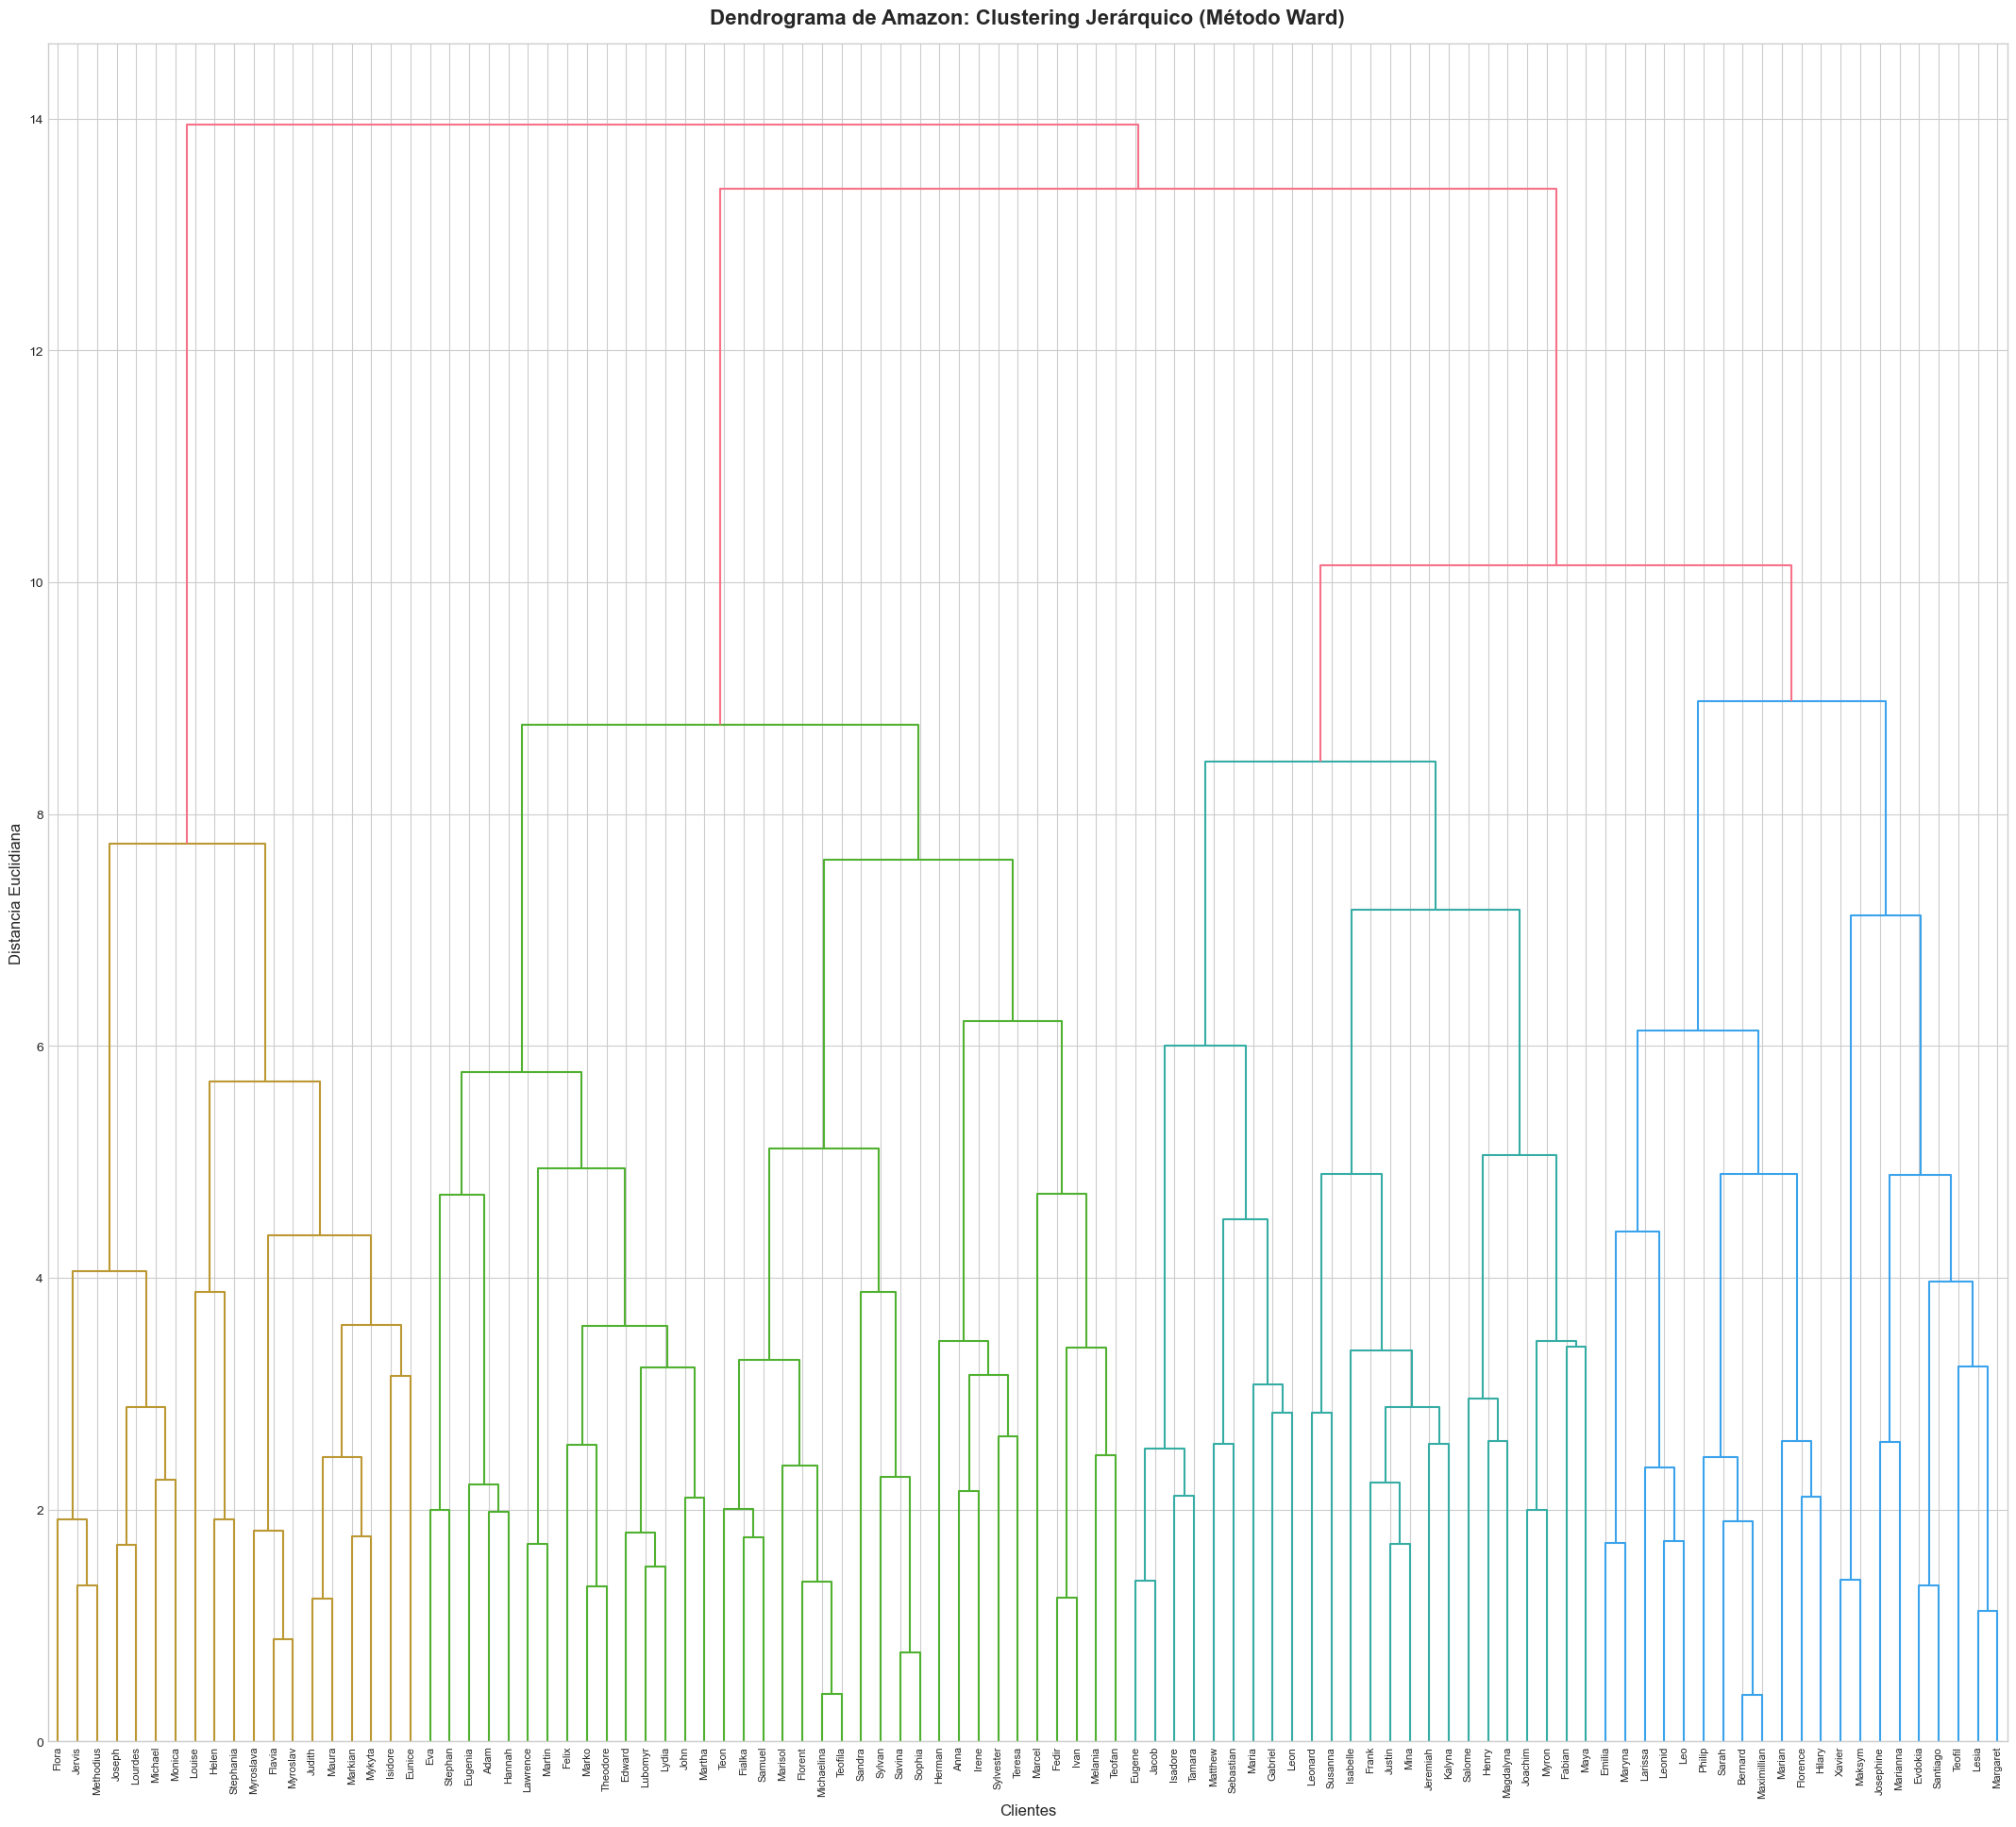

In [159]:
# ============================================================
# DENDROGRAMA
# ============================================================

# Dendrograma con método Ward
Z = linkage(df_scaled, method='ward', metric='euclidean')

# Visualización
plt.figure(figsize=(22,20))
plt.title('Dendrograma de Amazon: Clustering Jerárquico (Método Ward)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Clientes', fontsize=12)
plt.ylabel('Distancia Euclidiana', fontsize=12)

# Dendrograma completo
dend = dendrogram(
    Z,
    labels=df_scaled.index,
    leaf_rotation=90,
    leaf_font_size=8,
)

plt.tight_layout(pad=3.0)
plt.savefig('dend_amazon.png', dpi=150, bbox_inches='tight')
plt.show()

# Determinación del Número Óptimo de Clústeres

In [160]:
colores_unicos = set(dend['color_list'])
num_clusters_optimo = len(colores_unicos) - 1
print(f'Número óptimo de clusters 𝑘 = {num_clusters_optimo}')

Número óptimo de clusters 𝑘 = 4


# Dendrograma con umbral de clusters 𝑘 = 4

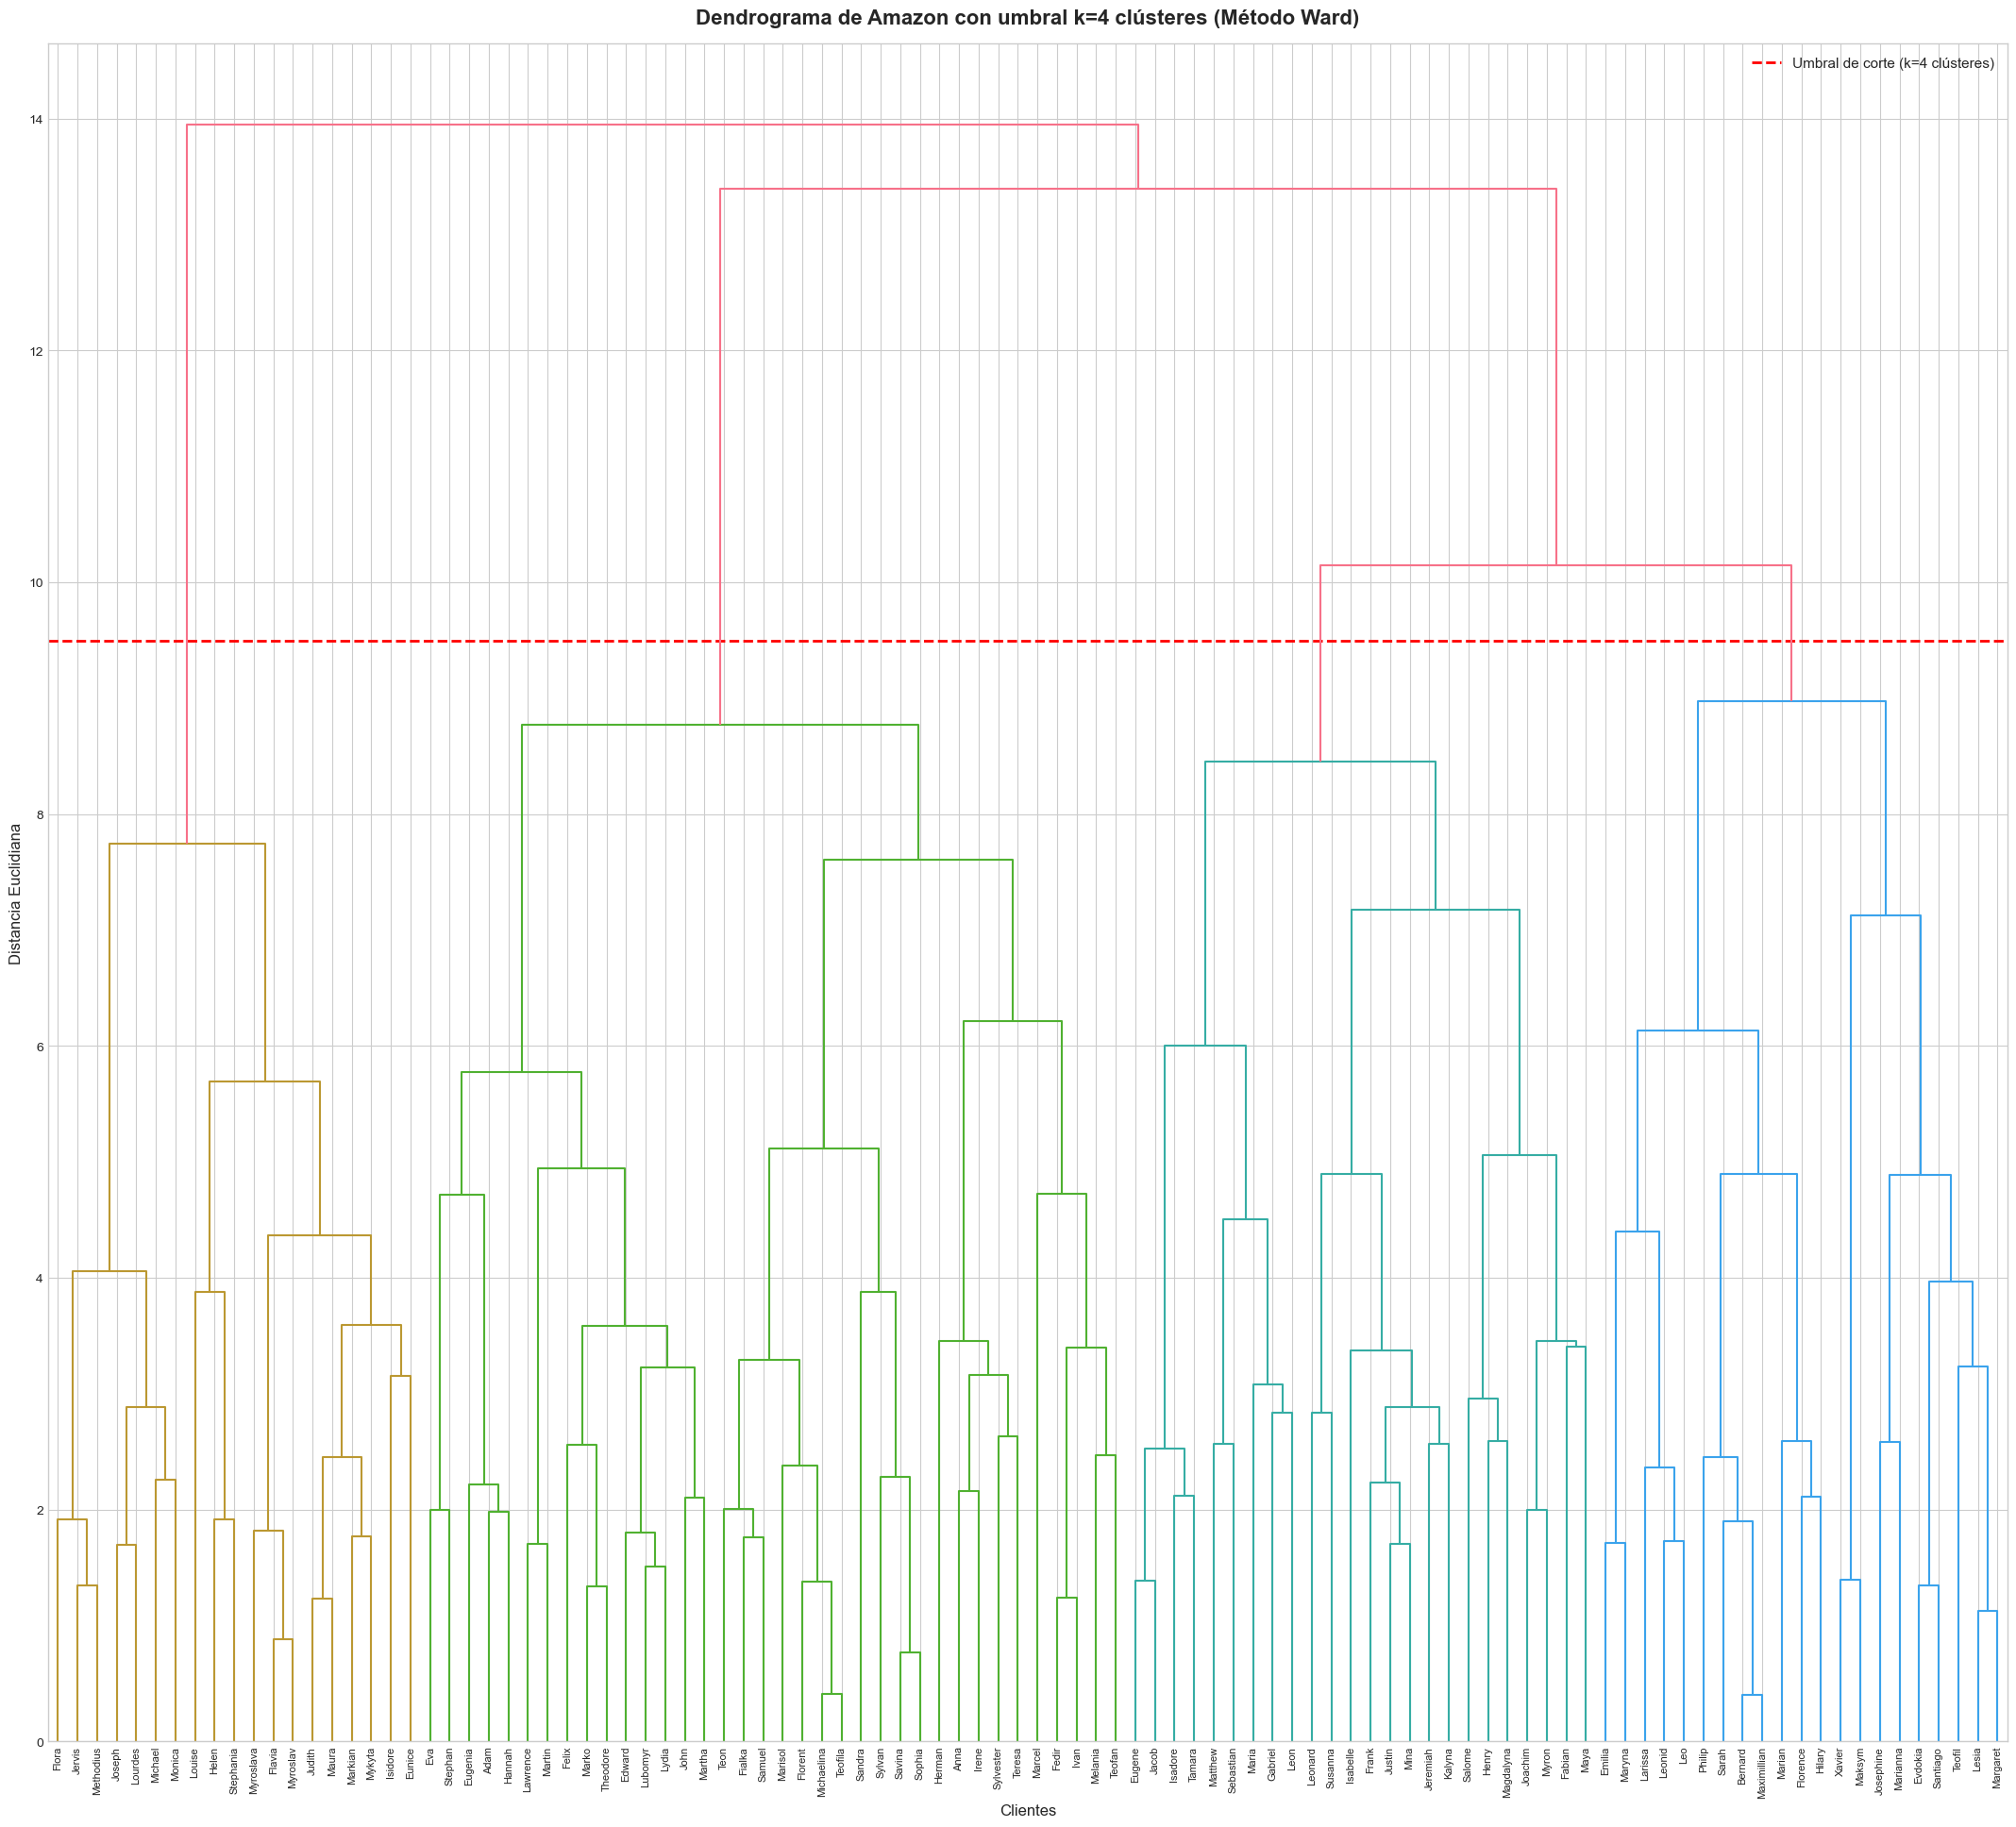

In [161]:
# ============================================================
# DENDROGRAMA CON UMBRAL 𝑘 = 4
# ============================================================

# Dendrograma con método Ward
Z = linkage(df_scaled, method='ward', metric='euclidean')

# Visualización
plt.figure(figsize=(22,20))
plt.title('Dendrograma de Amazon con umbral k=4 clústeres (Método Ward)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Clientes', fontsize=12)
plt.ylabel('Distancia Euclidiana', fontsize=12)
plt.axhline(y=9.5, color='red', linestyle='--', linewidth=2, label='Umbral de corte (k=4 clústeres)')
plt.legend(fontsize=11)

# Dendrograma completo
dend = dendrogram(
    Z,
    labels=df_scaled.index,
    leaf_rotation=90,
    leaf_font_size=8,
)

plt.tight_layout(pad=3.0)
plt.savefig('dend_umbral_amazon.png', dpi=150, bbox_inches='tight')
plt.show()

# Asignación de Clústeres (k=4)

In [162]:
# ============================================================
# ASIGNACIÓN DE CLÚSTERES
# ============================================================

K = 4  # Número de clústeres seleccionado

df['Cluster'] = fcluster(Z, K, criterion='maxclust')
df_scaled['Cluster'] = df['Cluster']

print('⎯' * 60)
print(f"ASIGNACIÓN DE {K} CLÚSTERES")
print('⎯' * 60)

# Mostrar distribución
cluster_counts = df['Cluster'].value_counts().sort_index()
print("\n Distribución de clientes por clúster:")
for cluster, count in cluster_counts.items():
    print(f"   Clúster {cluster}: {count} clientes ({count}%)")

# Mostrar integrantes de cada clúster
print('\n' + '⎯' * 60)
print("INTEGRANTES POR CLÚSTER")
print('⎯' * 60)
for i in range(1, K+1):
    members = df[df['Cluster'] == i].index.tolist()
    print(f"\n⋆ CLÚSTER {i} ({len(members)} clientes):")
    # Imprimir en filas de 8
    for j in range(0, len(members), 8):
        print("   " + " | ".join(members[j:j+8]))

⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
ASIGNACIÓN DE 4 CLÚSTERES
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯

 Distribución de clientes por clúster:
   Clúster 1: 19 clientes (19%)
   Clúster 2: 36 clientes (36%)
   Clúster 3: 24 clientes (24%)
   Clúster 4: 21 clientes (21%)

⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
INTEGRANTES POR CLÚSTER
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯

⋆ CLÚSTER 1 (19 clientes):
   Isidore | Joseph | Eunice | Flavia | Flora | Helen | Lourdes | Jervis
   Judith | Louise | Markian | Maura | Methodius | Michael | Monica | Mykyta
   Myroslav | Myroslava | Stephania

⋆ CLÚSTER 2 (36 clientes):
   Adam | Anna | Edward | Marisol | Irene | Eugenia | Eva | Fedir
   Felix | Fialka | Florent | Hannah | Herman | Ivan | John | Lawrence
   Lubomyr | Lydia | Marcel | Marko | Martha | Martin | Melania | Michaelina
   Samuel | Sandra | Savina | Sophia | Stephan | Sylvan | Sylvester | Theodore
  

# Perfil de Cada Clúster

PERFIL PROMEDIO DE CADA CLÚSTER (valores originales)
Cluster                 1       2       3       4
Velocidad Entrega  153.21   72.25   50.92  113.81
Precio              58.47   35.69  102.29   46.86
Durabilidad        440.26  211.00  182.25  165.48
Imagen Producto    188.47  137.50  168.79   85.95
Valor Educativo     30.68   20.58   22.04   33.48
Servicio Retorno    21.84   20.69   27.50   26.95
Tamano Paquete     112.05   61.42  336.33  150.71
Calidad Producto   264.47  124.83   80.88   69.52
Numero Estrellas    37.11   17.75   28.62   37.67



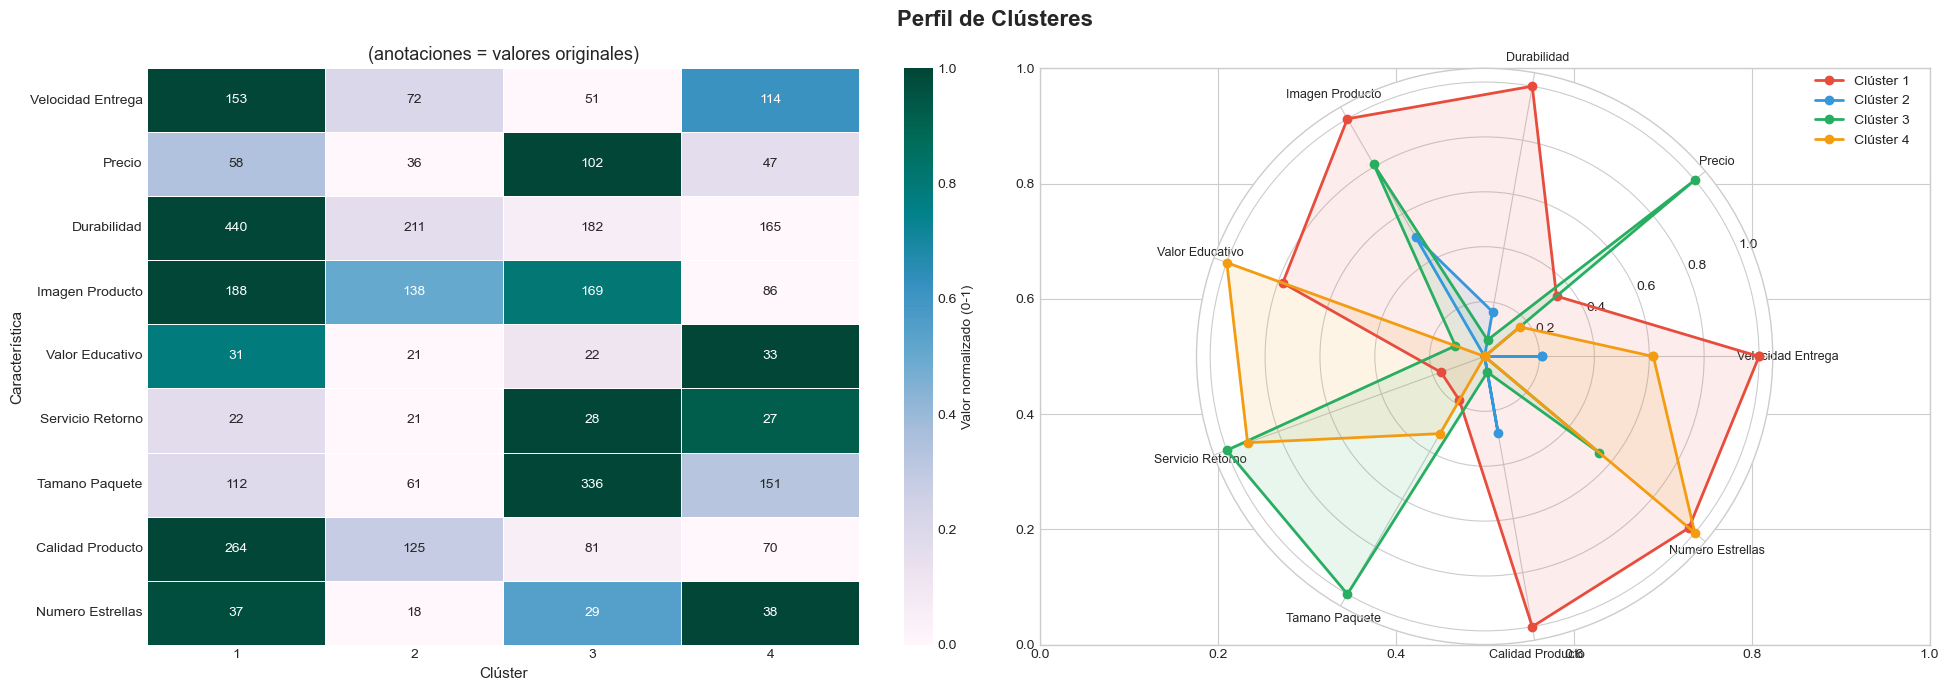

In [163]:
# ============================================================
# PERFIL DE CLÚSTERES
# ============================================================
features = [col for col in df.columns if col != 'Cluster']

cluster_profile = df.groupby('Cluster')[features].mean().round(2)

print("=" * 70)
print("PERFIL PROMEDIO DE CADA CLÚSTER (valores originales)")
print("=" * 70)
print(cluster_profile.T.to_string())
print()

# Visualización de perfiles
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ── Heatmap valores originales normalizados por columna ──
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / \
                       (cluster_profile.max() - cluster_profile.min())

sns.heatmap(
    cluster_profile_norm.T,
    annot=cluster_profile.T,
    fmt='.0f',
    cmap='PuBuGn',
    ax=axes[0],
    linewidths=0.5,
    cbar_kws={'label': 'Valor normalizado (0-1)'}
)
axes[0].set_title('(anotaciones = valores originales)', fontsize=13)
axes[0].set_xlabel('Clúster', fontsize=11)
axes[0].set_ylabel('Característica', fontsize=11)

# ── Radar chart por clúster ──
from matplotlib.patches import FancyArrowPatch
categories = features
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_radar = axes[1]
ax_radar = plt.subplot(122, polar=True)

colors_radar = ['#E74C3C', '#3498DB', '#27AE60', '#F39C12']
labels_cluster = ['Clúster 1', 'Clúster 2', 'Clúster 3', 'Clúster 4']

for idx, (cluster_id, row) in enumerate(cluster_profile_norm.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax_radar.plot(angles, values, 'o-', linewidth=2, color=colors_radar[idx], label=labels_cluster[idx])
    ax_radar.fill(angles, values, alpha=0.1, color=colors_radar[idx])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, size=9)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.26, 1.01))

plt.suptitle('Perfil de Clústeres', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('dend_perfil_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Sistema de Recomendaciones para Clientes Objetivo

In [164]:
# ============================================================
# FUNCIÓN COMPLETA DE RECOMENDACIÓN CON VISUALIZACIÓN
# ============================================================

def recomendar_con_detalle(nombre, df, top_n=3):
    """
    Encuentra los clientes más similares (menor distancia euclidiana) 
    dentro del mismo clúster y genera recomendaciones.  
    """
    features = [c for c in df.columns if c != 'Cluster']
    
    if nombre not in df.index:
        print(f"✗ {nombre} no encontrado")
        return
    
    cluster_id = df.loc[nombre, 'Cluster']
    compañeros = df[(df['Cluster'] == cluster_id) & (df.index != nombre)]
    
    # ─── Calcular distancias euclidianas ───
    vec_objetivo = df.loc[nombre, features].values
    distancias = {}
    
    for comp in compañeros.index:
        vec_comp = df.loc[comp, features].values
        dist = np.linalg.norm(vec_objetivo - vec_comp)
        distancias[comp] = round(dist, 2)
    
    # ─── Ordenar de menor a mayor distancia ───
    distancias_ord = dict(sorted(distancias.items(), key=lambda x: x[1]))
    
    top_lista = list(distancias_ord.items())[:top_n]
    
    # ─── Imprimir resultados ───
    print('\n' + '═'*65)
    print(f"RECOMENDACIONES PARA: {nombre.upper()}")
    print("═"*65)
    print(f"  ⋆ Clúster: {cluster_id}")

    nombres_clusteres = {
        1: "Compradores Premium (Alta Calidad)",
        2: "Compradores Moderados (Precio-Conscientes)",
        3: "Compradores de Volumen (Grandes Compras)",
        4: "Compradores con Propósito (Valor Educativo)"
    }
    print(f"  ⋆ Perfil: '{nombres_clusteres[cluster_id]}'")
    print(f"  ⋆ Compañeros en clúster: {len(compañeros)}")
    
    print(f"\n  ⋆ Perfil de {nombre}:")
    for feat in features:
        print(f"     {feat:<18} → {df.loc[nombre, feat]:>6.2f}")
    
    print(f"\n  ✪ TOP {top_n} CLIENTES MÁS SIMILARES:")
    print(f"     {'Rank':<5} {'Cliente':<10} {'Distancia':>10}  Interpretación")
    print(f"     {'─' * 46}")
    
    for rank, (comp, dist) in enumerate(top_lista, 1):
        if rank == 1:
            grade = "MEJOR"
        elif rank == 2:
            grade = "2da"
        else:
            grade = "3ra"
        print(f"     {rank:<5} {comp:<10} {dist:>10.2f}  {grade} opción")
    
    # ─── Recomendación final en texto ───
    mejor = top_lista[0][0]
    print(f"""
  RECOMENDACIÓN FINAL:
    Se recomienda a {nombre} los mismos productos que compró: {mejor}
    (menor distancia euclidiana = máxima similitud)
    """)
    
    # ─── Tabla comparativa detallada ───
    print(f"  COMPARATIVA: {nombre} vs {mejor}")
    print(f"    {'Característica':<18} {nombre:>12} {mejor:>12} {'Dif':>10}")
    print(f"    {'─'*58}")
    
    for feat in features:
        v1 = df.loc[nombre, feat]
        v2 = df.loc[mejor, feat]
        diff = abs(v1 - v2)
        icon = "🟢" if diff < 30 else ("🟡" if diff < 80 else "🔴")
        print(f"    {feat:<18} {v1:>12.2f} {v2:>12.2f} {diff:>9.2f}  {icon}")
    
    return [c for c, _ in top_lista]


# ─────────────────────────────────────────────────────────────
# EJECUTAR PARA LOS 3 CLIENTES OBJETIVO
# ─────────────────────────────────────────────────────────────
r_salome = recomendar_con_detalle('Salome', df, top_n=3)
r_stephania = recomendar_con_detalle('Stephania', df, top_n=3)
r_lydia = recomendar_con_detalle('Lydia', df, top_n=3)


═════════════════════════════════════════════════════════════════
RECOMENDACIONES PARA: SALOME
═════════════════════════════════════════════════════════════════
  ⋆ Clúster: 3
  ⋆ Perfil: 'Compradores de Volumen (Grandes Compras)'
  ⋆ Compañeros en clúster: 23

  ⋆ Perfil de Salome:
     Velocidad Entrega  →  17.00
     Precio             →  23.00
     Durabilidad        → 275.00
     Imagen Producto    →  41.00
     Valor Educativo    →   4.00
     Servicio Retorno   →  44.00
     Tamano Paquete     → 315.00
     Calidad Producto   →  28.00
     Numero Estrellas   →  32.00

  ✪ TOP 3 CLIENTES MÁS SIMILARES:
     Rank  Cliente     Distancia  Interpretación
     ──────────────────────────────────────────────
     1     Magdalyna      184.96  MEJOR opción
     2     Kalyna         192.47  2da opción
     3     Gabriel        207.26  3ra opción

  RECOMENDACIÓN FINAL:
    Se recomienda a Salome los mismos productos que compró: Magdalyna
    (menor distancia euclidiana = máxima similitud)

# Visualización Comparativa de las 3 Clientes Objetivo

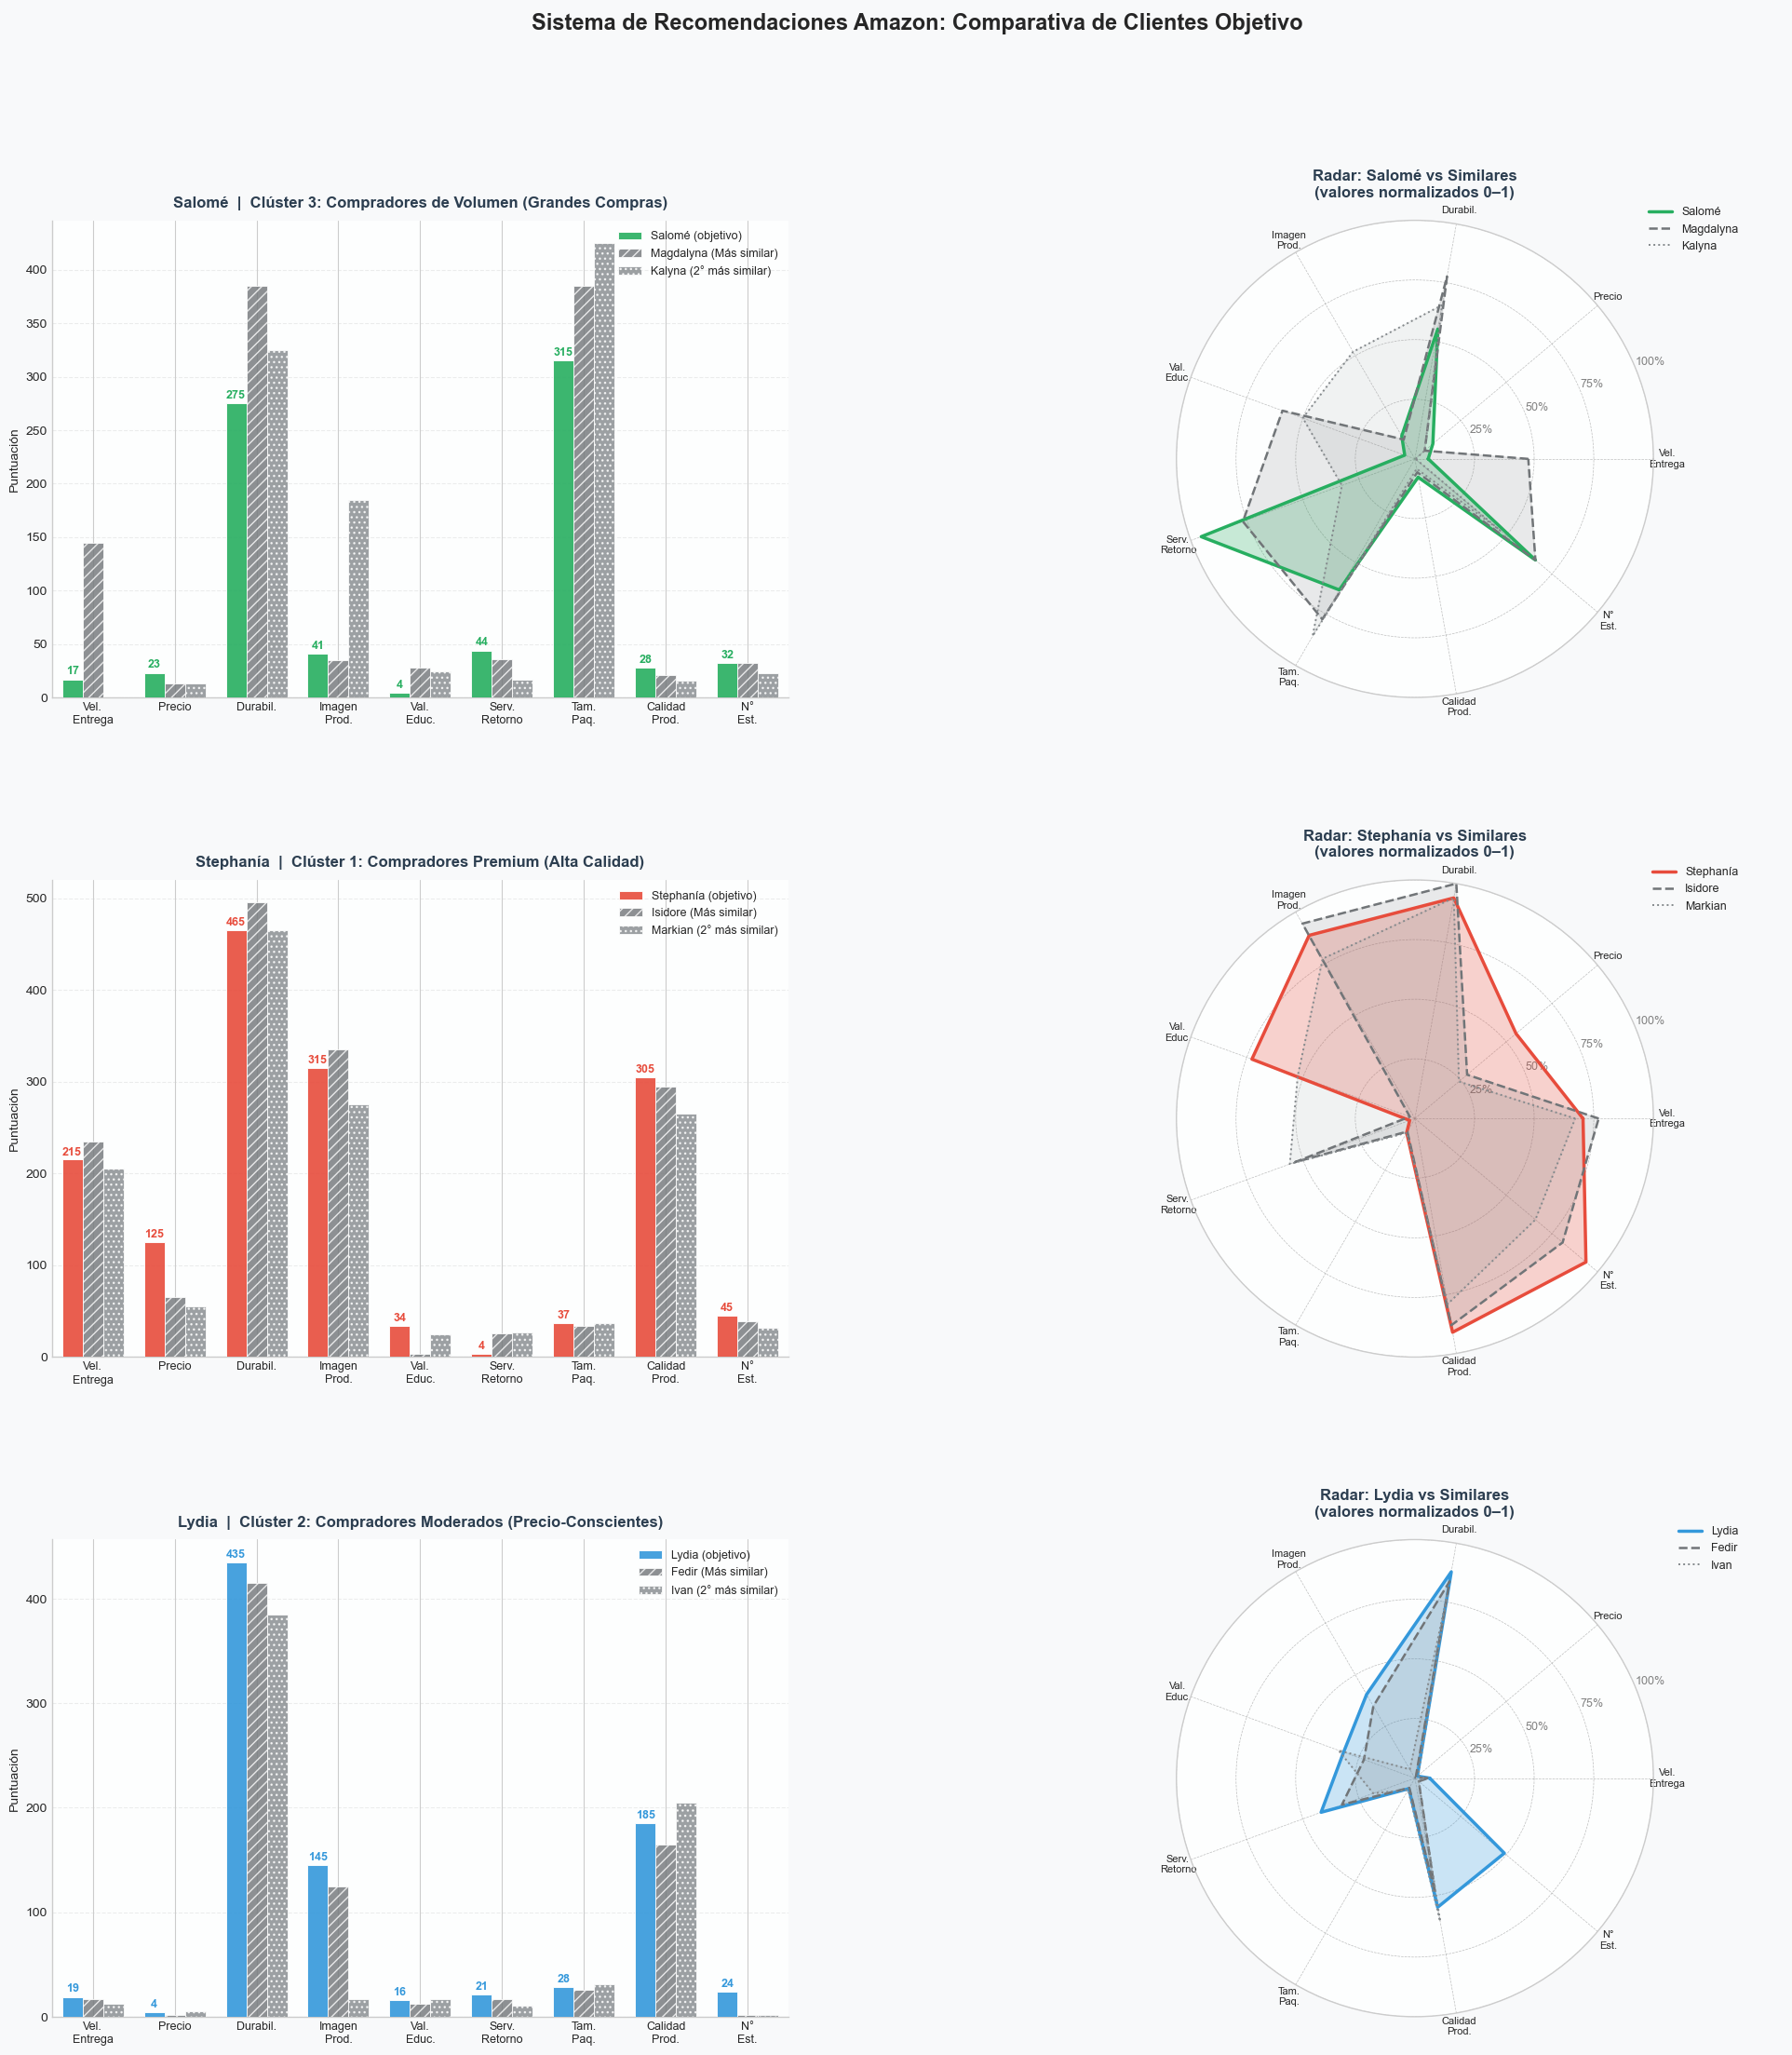

In [165]:
# ============================================================
# VISUALIZACIÓN COMPARATIVA DE LAS 3 CLIENTES OBJETIVO
# ============================================================

# ── Definir Features ──
cols_excluir = ['Cluster', 'PC1', 'PC2']
features = [c for c in df.columns if c not in cols_excluir]

# ── Etiquetas cortas ──
labels_short = [
    'Vel.\nEntrega', 'Precio', 'Durabil.',
    'Imagen\nProd.', 'Val.\nEduc.', 'Serv.\nRetorno',
    'Tam.\nPaq.', 'Calidad\nProd.', 'N°\nEst.'
]

# ── Ángulos radar ──
N = len(features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # cierra el polígono


# ── Normalización para radar (0-1 por columna) ──
df_features = df[features]
df_norm_radar = (df_features - df_features.min()) / \
                (df_features.max() - df_features.min())

# ── Configuración de clientes objetivo ──
clientes_obj = {
    'Salomé': {
        'nombre_real':     'Salome',
        'cluster':          3,
        'perfil':          'Compradores de Volumen (Grandes Compras)',
        'top':             ['Magdalyna', 'Kalyna'],
        'color_principal': '#27AE60',
    },
    'Stephanía': {
        'nombre_real':     'Stephania',
        'cluster':          1,
        'perfil':          'Compradores Premium (Alta Calidad)',
        'top':             ['Isidore', 'Markian'],
        'color_principal': '#E74C3C',
    },
    'Lydia': {
        'nombre_real':     'Lydia',
        'cluster':          2,
        'perfil':          'Compradores Moderados (Precio-Conscientes)',
        'top':             ['Fedir', 'Ivan'],
        'color_principal': '#3498DB',
    }
}

# ════════════════════════════════════════════════════════════
# FIGURA: 4 filas (1 título + 3 clientes) × 2 columnas
# ════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(24, 28))
fig.patch.set_facecolor('#F8F9FA')

gs = GridSpec(
    4, 2, figure=fig,
    hspace=0.50, wspace=0.35,
    height_ratios=[0.06, 1, 1, 1]
)

# ── Título general ──
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(
    0.5, 0.5,
    'Sistema de Recomendaciones Amazon: Comparativa de Clientes Objetivo',
    ha='center', va='center', fontsize=17, fontweight='bold')

# ════════════════════════════════════════════════════════════
# LOOP: una fila por cliente
# ════════════════════════════════════════════════════════════
for row_idx, (display_name, info) in \
        enumerate(clientes_obj.items(), start=1):

    nombre_real  = info['nombre_real']
    top_clientes = info['top'] # 2 más similares
    color_p      = info['color_principal']
    cluster_id   = info['cluster']
    perfil_txt   = info['perfil']

    # ── BARRAS ──
    ax_bar = fig.add_subplot(gs[row_idx, 0])
    ax_bar.set_facecolor('#FDFEFE')

    n_feat = len(features) # 9
    x      = np.arange(n_feat) # [0..8]
    width  = 0.25

    # Barras del cliente objetivo
    vals_obj = df.loc[nombre_real, features].values
    bars0 = ax_bar.bar(
        x - width, vals_obj, width,
        label=f'{display_name} (objetivo)',
        color=color_p, alpha=0.90,
        edgecolor='white', linewidth=0.7, zorder=3
    )

    # Barras de los 2 similares
    comp_colors = ['#717578', '#84898C'] 
    hatches     = ['///', '...']
    rank_labels = ['Más similar', '2° más similar']

    for i, comp_name in enumerate(top_clientes):
        vals_comp = df.loc[comp_name, features].values
        ax_bar.bar(
            x + (i * width), vals_comp, width,
            label=f'{comp_name} ({rank_labels[i]})',
            color=comp_colors[i], alpha=0.80,
            edgecolor='white', linewidth=0.7,
            hatch=hatches[i], zorder=3
        )

    # Fijar límites ANTES de set_xticks
    ax_bar.set_xlim(-0.5, n_feat - 0.5)
    ax_bar.set_xticks(x)              
    ax_bar.set_xticklabels(labels_short, rotation=0, ha='center', fontsize=9)
    ax_bar.set_title(
        f'{display_name}  |  Clúster {cluster_id}: {perfil_txt}',
        fontsize=12, fontweight='bold',  color='#2C3E50', pad=10
    )
    ax_bar.set_ylabel('Puntuación', fontsize=10)
    ax_bar.legend(fontsize=9, loc='upper right', framealpha=0.9, edgecolor='#CCC')
    ax_bar.grid(axis='y', alpha=0.35, linestyle='--')
    ax_bar.spines[['top', 'right']].set_visible(False)

    # Valores encima de barras del objetivo
    for bar in bars0:
        h = bar.get_height()
        ax_bar.text(
            bar.get_x() + bar.get_width() / 2,
            h + 2, f'{int(h)}',
            ha='center', va='bottom',
            fontsize=9, color=color_p, fontweight='bold'
        )

    # ── RADAR ──
    ax_rad = fig.add_subplot(gs[row_idx, 1], polar=True)
    ax_rad.set_facecolor('#FDFEFE')

    todos_radar  = [nombre_real] + top_clientes
    names_radar  = [display_name] + top_clientes
    colors_radar = [color_p, '#717578', '#84898C']
    alphas_radar = [0.25, 0.15, 0.10]
    lw_radar     = [2.5, 1.8, 1.4]
    ls_radar     = ['-', '--', ':']

    for idx_r, client in enumerate(todos_radar):
        vals_r  = df_norm_radar.loc[client, features].tolist()
        vals_r += vals_r[:1] # cierra polígono

        ax_rad.plot(
            angles, vals_r,
            color=colors_radar[idx_r],
            linewidth=lw_radar[idx_r],
            linestyle=ls_radar[idx_r],
            label=names_radar[idx_r], zorder=3
        )
        ax_rad.fill(
            angles, vals_r,
            color=colors_radar[idx_r],
            alpha=alphas_radar[idx_r]
        )

    ax_rad.set_xticks(angles[:-1])
    ax_rad.set_xticklabels(labels_short, fontsize=8)
    ax_rad.set_ylim(0, 1)
    ax_rad.set_yticks([0.25, 0.50, 0.75, 1.0])
    ax_rad.set_yticklabels(
        ['25%', '50%', '75%', '100%'],
        fontsize=9, color='grey'
    )
    ax_rad.set_title(
        f'Radar: {display_name} vs Similares\n'
        f'(valores normalizados 0–1)',
        fontsize=12, fontweight='bold', color='#2C3E50', pad=18
    )
    ax_rad.legend(
        loc='upper right',
        bbox_to_anchor=(1.2, 1.05),
        fontsize=9, framealpha=0.9
    )
    ax_rad.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

plt.savefig(
    'dend_comparativa_clientes_objetivo.png',
    dpi=150, bbox_inches='tight', facecolor='#F8F9FA'
)
plt.show()

# Visualización de Clústeres en 2D (PCA)

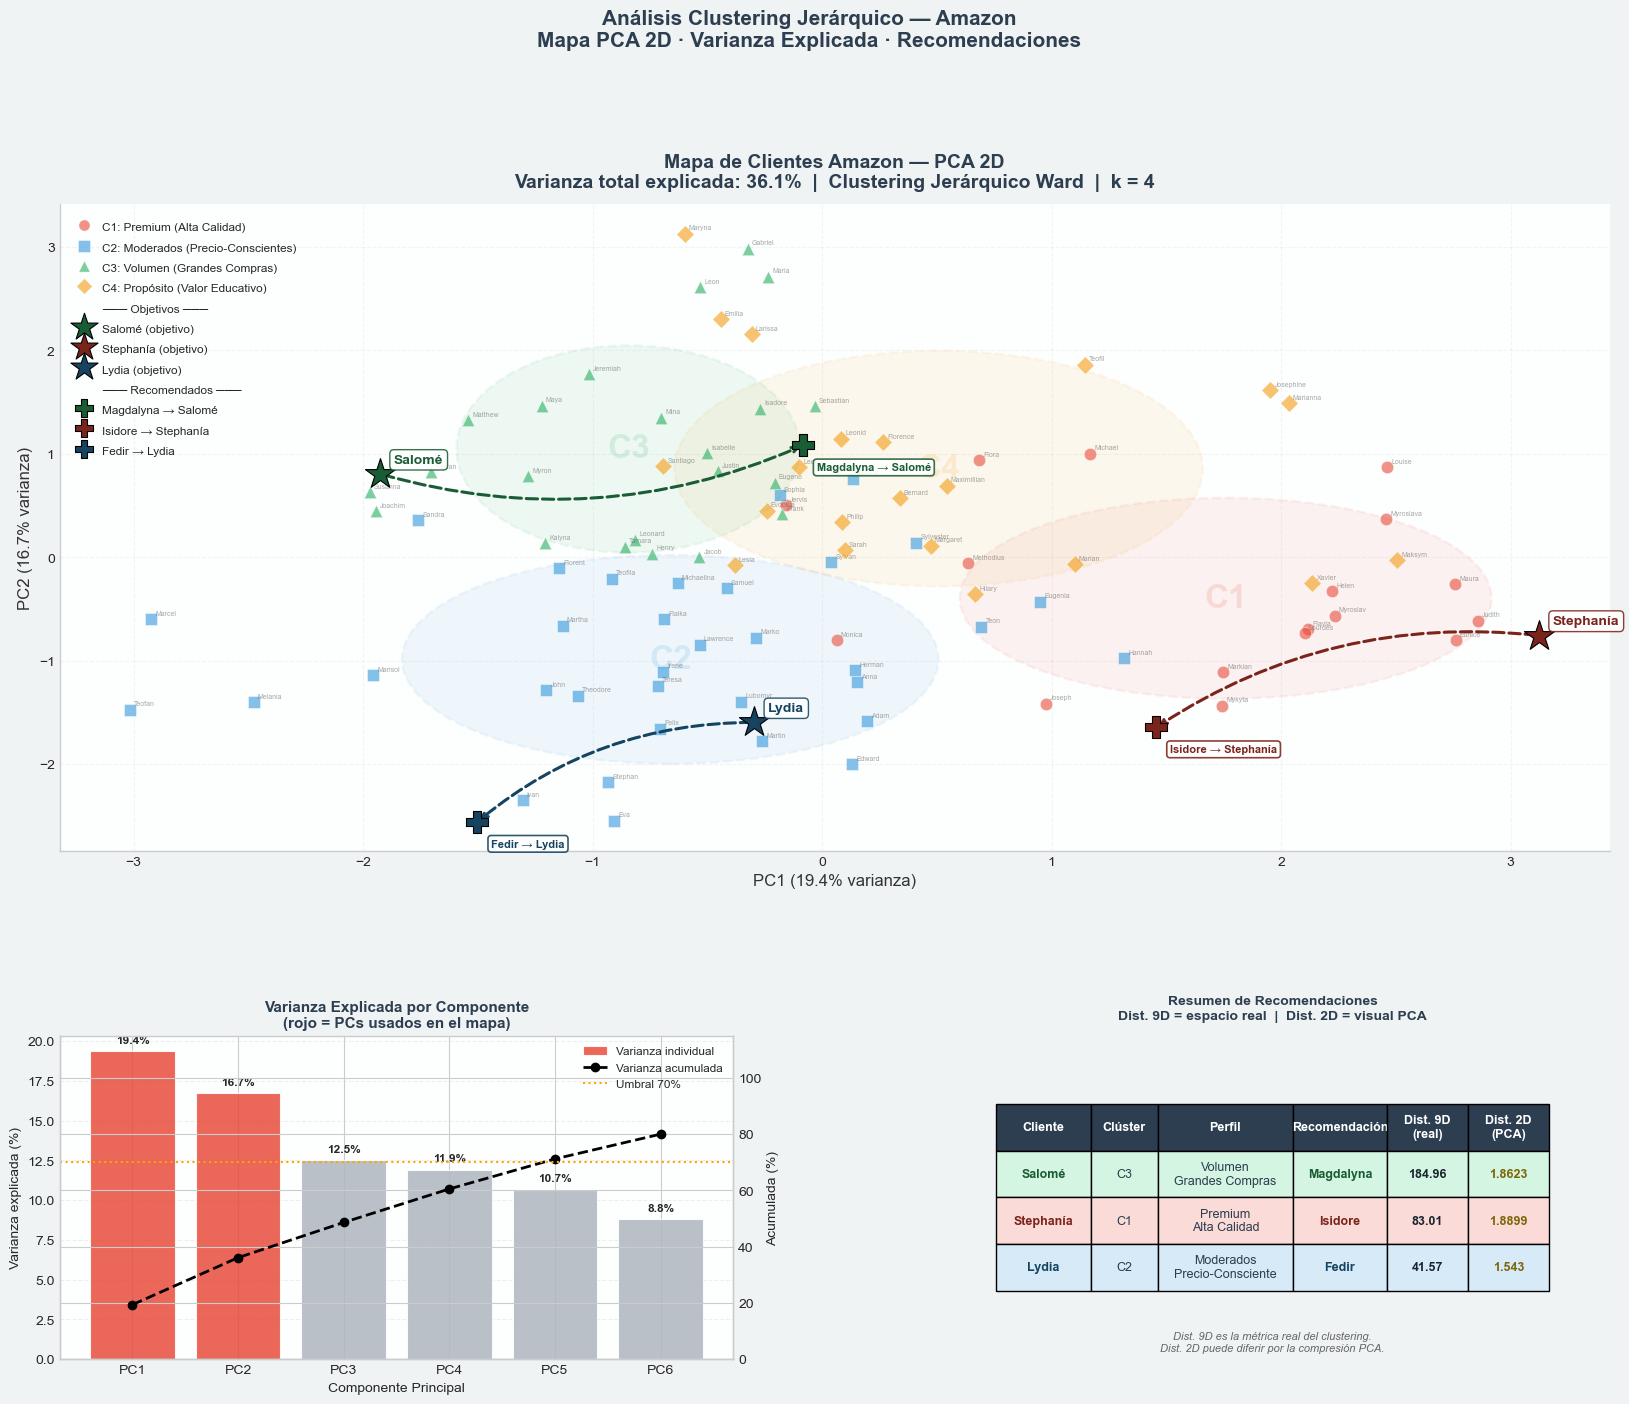

In [166]:
# ============================================================
# VISUALIZACIÓN PCA 2D
# ============================================================

# ── Escalar y calcular PCA ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

var_pc1 = pca.explained_variance_ratio_[0] * 100 # Combinación lineal de las 9 variables que captura la MAYOR varianza posible
var_pc2 = pca.explained_variance_ratio_[1] * 100 # Captura la segunda mayor varianza, perpendicular a PC1
var_tot = var_pc1 + var_pc2

df['PC1'] = X_pca[:, 0] # Primera Componente Principal
df['PC2'] = X_pca[:, 1] # Segunda Componente Principal  

# ── Paletas ──
colores_cluster = {
    1: '#E74C3C',
    2: '#3498DB',
    3: '#27AE60',
    4: '#F39C12'
}
nombres_cluster = {
    1: 'C1: Premium (Alta Calidad)',
    2: 'C2: Moderados (Precio-Conscientes)',
    3: 'C3: Volumen (Grandes Compras)',
    4: 'C4: Propósito (Valor Educativo)'
}
markers_cluster = {1: 'o', 2: 's', 3: '^', 4: 'D'}

# Clientes objetivo y sus recomendados
obj_info = {
    'Salome':    ('Salomé',    '#1A5C34'),
    'Stephania': ('Stephanía', '#7B241C'),
    'Lydia':     ('Lydia',     '#154360'),
}
sim_info = {
    'Magdalyna': ('→ Salomé',    '#1A5C34'),
    'Isidore':   ('→ Stephanía', '#7B241C'),
    'Fedir':     ('→ Lydia',     '#154360'),
}
pares_flechas = [
    ('Salome',    'Magdalyna', '#1A5C34'),
    ('Stephania', 'Isidore',   '#7B241C'),
    ('Lydia',     'Fedir',     '#154360'),
]

# Configuración de cada recomendado
recomendados_cfg = [
    ('Magdalyna', 'Magdalyna → Salomé',  '#1A5C34'),
    ('Isidore',   'Isidore → Stephanía', '#7B241C'),
    ('Fedir',     'Fedir → Lydia',       '#154360'),
]

# ── Layout ──
fig2 = plt.figure(figsize=(20, 15))
fig2.patch.set_facecolor('#F0F3F4')

gs2 = GridSpec(
    2, 2, figure=fig2,
    hspace=0.38, wspace=0.30,
    height_ratios=[2, 1]
)

# ════════════════════════════════════════════════════════════
# PANEL PRINCIPAL: Mapa 2D
# ════════════════════════════════════════════════════════════
ax_main = fig2.add_subplot(gs2[0, :])
ax_main.set_facecolor('#FDFEFE')

todos_destacados = list(obj_info.keys()) + list(sim_info.keys())

# ── Puntos normales (no destacados)
for cid in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cid
    sub  = df[mask & ~df.index.isin(todos_destacados)]

    ax_main.scatter(
        sub['PC1'], sub['PC2'],
        c=colores_cluster[cid],
        marker=markers_cluster[cid],
        s=80, alpha=0.60,
        edgecolors='white', linewidth=0.5,
        label=nombres_cluster[cid],
        zorder=3
    )
    for idx_name in sub.index:
        ax_main.annotate(
            idx_name,
            (df.loc[idx_name, 'PC1'],
             df.loc[idx_name, 'PC2']),
            fontsize=5, alpha=0.50,
            color='#555',
            xytext=(3, 3),
            textcoords='offset points'
        )

# ── Clientes objetivo ★
for nombre_r, (display, color_d) in obj_info.items():
    pc1 = df.loc[nombre_r, 'PC1']
    pc2 = df.loc[nombre_r, 'PC2']
    ax_main.scatter(
        pc1, pc2,
        c=color_d, marker='*', s=520,
        edgecolors='black', linewidth=0.8,
        zorder=7,
        label=f'{display} (objetivo)'
    )
    # Anotación de texto junto al punto
    ax_main.annotate(
        f'{display}',
        (pc1, pc2),
        fontsize=10, fontweight='bold', color=color_d,
        xytext=(10, 8), textcoords='offset points',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor=color_d, alpha=0.88
        ),
        zorder=8
    )

# ── Clientes recomendados ✚
for nombre_s, label_leyenda, color_s in recomendados_cfg:
    pc1_s = df.loc[nombre_s, 'PC1']
    pc2_s = df.loc[nombre_s, 'PC2']
    ax_main.scatter(
        pc1_s, pc2_s,
        c=color_s,
        marker='P',
        s=230,
        edgecolors='black',
        linewidth=0.8,
        zorder=6,
        label=f'{label_leyenda}'
    )
    # Anotación de texto junto al punto
    ax_main.annotate(
        label_leyenda,
        (pc1_s, pc2_s),
        fontsize=8,
        fontweight='bold',
        color=color_s,
        xytext=(10, -18),
        textcoords='offset points',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor=color_s,
            alpha=0.88,
            linewidth=1.2
        ),
        zorder=7
    )

# ── Flechas de recomendado a objetivo →
for origen, destino, color_f in pares_flechas:
    ax_main.annotate(
        '',
        xy=(df.loc[destino, 'PC1'],
            df.loc[destino, 'PC2']),
        xytext=(df.loc[origen, 'PC1'],
                df.loc[origen, 'PC2']),
        arrowprops=dict(
            arrowstyle='->',
            color=color_f,
            lw=2.2,
            linestyle='dashed',
            connectionstyle='arc3, rad=0.18'
        ),
        zorder=5
    )

# ── Elipses de región por clúster ──
for cid in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cid
    sub  = df[mask]
    cx   = sub['PC1'].mean()
    cy   = sub['PC2'].mean()
    sx   = sub['PC1'].std() * 2.4
    sy   = sub['PC2'].std() * 2.4

    elipse = Ellipse(
        (cx, cy), width=sx, height=sy,
        facecolor=colores_cluster[cid], alpha=0.07,
        edgecolor=colores_cluster[cid],
        linewidth=1.8, linestyle='--', zorder=1
    )
    ax_main.add_patch(elipse)

    ax_main.text(
        cx, cy, f'C{cid}',
        ha='center', va='center',
        fontsize=24, fontweight='bold',
        color=colores_cluster[cid],
        alpha=0.15, zorder=2
    )
    
# ── Leyenda con separador visual entre grupos ──

# Crear handles manuales para mejor control visual
handles, labels_leg = ax_main.get_legend_handles_labels()

# Separador vacío entre clústeres y objetivos
separador = mpatches.Patch(
    color='none', label='─────────────────'
)

# Insertar separadores
handles.insert(4, separador) # posición 4 (entre clústeres y estrellas)
labels_leg.insert(4, '─── Objetivos ───')

handles.insert(8, separador) # posición 8 (entre estrellas y recomendados)
labels_leg.insert(8, '─── Recomendados ───')

ax_main.legend(
    handles=handles,
    labels=labels_leg,
    loc='upper left',
    fontsize=8.5,
    framealpha=0.92,
    edgecolor='#CCC',
    ncol=1,
    markerscale=0.9,
    handlelength=1.5,
    handleheight=1.5,
    borderpad=0.8
)

# ── Formato panel principal ──
ax_main.set_xlabel(f'PC1 ({var_pc1:.1f}% varianza)', fontsize=12, color='#333')
ax_main.set_ylabel(f'PC2 ({var_pc2:.1f}% varianza)', fontsize=12, color='#333')
ax_main.set_title(
    f'Mapa de Clientes Amazon — PCA 2D\n'
    f'Varianza total explicada: {var_tot:.1f}%  |  '
    f'Clustering Jerárquico Ward  |  k = 4',
    fontsize=14, fontweight='bold',
    color='#2C3E50', pad=12
)
ax_main.grid(True, alpha=0.22, linestyle='--')
ax_main.spines[['top', 'right']].set_visible(False)


# ════════════════════════════════════════════════════════════
# PANEL INFERIOR IZQ: Varianza explicada
# ════════════════════════════════════════════════════════════
ax_var = fig2.add_subplot(gs2[1, 0])
ax_var.set_facecolor('#FDFEFE')

# ── Preparación del PCA ──
n_pcs    = min(6, len(features_orig))
pca_full = PCA(n_components=n_pcs).fit(X_scaled_pca)
var_ind  = pca_full.explained_variance_ratio_ * 100
var_cum  = np.cumsum(var_ind)

# ── Barras de varianza individual ──
bars_v = ax_var.bar(
    range(1, n_pcs + 1), var_ind,
    color=['#E74C3C' if i < 2 else '#AEB6BF' # PC1 y PC2 → rojo
           for i in range(n_pcs)],
    edgecolor='white', linewidth=0.8,
    alpha=0.85,
    label='Varianza individual'
)

# ── Eje secundario ──
ax_var2 = ax_var.twinx()
# Curva de varianza acumulada
line1, = ax_var2.plot(
    range(1, n_pcs + 1), var_cum,
    'ko--', linewidth=2, markersize=6,
    label='Varianza acumulada'
)
# Umbral de referencia de PCs usados
line2 = ax_var2.axhline(
    y=70, color='orange', linestyle=':',
    linewidth=1.5,
    label='Umbral 70%'
)
ax_var2.set_ylabel('Acumulada (%)', fontsize=10)
ax_var2.set_ylim(0, 115)

# ── Etiquetas encima de cada barra ──
for bar, val in zip(bars_v, var_ind):
    ax_var.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=8.5, fontweight='bold'
    )
ax_var.set_xlabel('Componente Principal', fontsize=10)
ax_var.set_ylabel('Varianza explicada (%)', fontsize=10)
ax_var.set_title(
    'Varianza Explicada por Componente\n'
    '(rojo = PCs usados en el mapa)',
    fontsize=11, fontweight='bold', color='#2C3E50'
)
ax_var.set_xticks(range(1, n_pcs + 1))
ax_var.set_xticklabels([f'PC{i}' for i in range(1, n_pcs + 1)])
ax_var.grid(axis='y', alpha=0.3, linestyle='--')
ax_var.spines[['top']].set_visible(False)

# ── Una sola leyenda combinada ──
# Recolectar handles de AMBOS ejes
handles_ax1, labels_ax1 = ax_var.get_legend_handles_labels()
handles_ax2 = [line1, line2]
labels_ax2 = ['Varianza acumulada', 'Umbral 70%']

# Quitar leyendas individuales (si existieran)
ax_var.legend_ = None
ax_var2.legend_ = None

# Crear leyenda única en ax_var (eje principal) upper right
ax_var.legend(
    handles_ax1 + handles_ax2,   # barras + líneas
    labels_ax1 + labels_ax2,     # sus etiquetas
    loc='upper right',
    fontsize=8.5,
    framealpha=0.92,
    edgecolor='#CCC',
    ncol=1
)

# ════════════════════════════════════════════════════════════
# PANEL INFERIOR DER: Tabla resumen con distancias 9D y 2D
# ════════════════════════════════════════════════════════════
ax_tab = fig2.add_subplot(gs2[1, 1])
ax_tab.axis('off')

# ── Calcular distancias 9D y 2D para cada par ──
features_orig = ['Velocidad Entrega', 'Precio', 'Durabilidad',
                 'Imagen Producto', 'Valor Educativo',
                 'Servicio Retorno', 'Tamano Paquete',
                 'Calidad Producto', 'Numero Estrellas']
pares = [
    ('Salome', 'Magdalyna'),
    ('Stephania', 'Isidore'),
    ('Lydia', 'Fedir'),
]

distancias = {}
for objetivo, recomendado in pares:
    # Distancia real en 9 dimensiones
    d_9d = np.linalg.norm(
        df.loc[objetivo, features_orig].values - df.loc[recomendado, features_orig].values
    )
    # Distancia visual en PCA 2D
    d_2d = np.linalg.norm(
        df.loc[objetivo, ['PC1','PC2']].values - df.loc[recomendado, ['PC1','PC2']].values
    )
    distancias[(objetivo, recomendado)] = (round(d_9d, 2), round(d_2d, 4))

# ── Datos de la tabla ──
cab = ['Cliente', 'Clúster', 'Perfil', 'Recomendación', 'Dist. 9D\n(real)', 'Dist. 2D\n(PCA)']

dat = [
    ['Salomé', 'C3', 'Volumen\nGrandes Compras', 'Magdalyna',
     f"{distancias[('Salome', 'Magdalyna')][0]}",
     f"{distancias[('Salome', 'Magdalyna')][1]}"],

    ['Stephanía', 'C1', 'Premium\nAlta Calidad', 'Isidore',
     f"{distancias[('Stephania', 'Isidore')][0]}",
     f"{distancias[('Stephania', 'Isidore')][1]}"],

    ['Lydia', 'C2', 'Moderados\nPrecio-Consciente','Fedir',
     f"{distancias[('Lydia', 'Fedir')][0]}",
     f"{distancias[('Lydia', 'Fedir')][1]}"],
]

# ── Crear tabla ──
tabla = ax_tab.table(cellText=dat, colLabels=cab, loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.15, 2.8)

# ── Estilo encabezado ──
for j in range(len(cab)):
    tabla[(0, j)].set_facecolor('#2C3E50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

# ── Estilo filas con nota en columnas de distancia ──
row_cfg = [
    ('#D5F5E3', '#1A5C34'),   # Salomé    → verde
    ('#FADBD8', '#7B241C'),   # Stephanía → rojo
    ('#D6EAF8', '#154360'),   # Lydia     → azul
]

for i, (bg, fg) in enumerate(row_cfg, start=1):
    for j in range(len(cab)):
        tabla[(i, j)].set_facecolor(bg)
        tabla[(i, j)].set_text_props(color='#2C3E50')

    # Columna cliente y recomendación en negrita con color
    tabla[(i, 0)].set_text_props(fontweight='bold', color=fg)
    tabla[(i, 3)].set_text_props(fontweight='bold', color=fg)

    # Columnas de distancia con color diferenciado
    tabla[(i, 4)].set_text_props(
        fontweight='bold', color='#1A252F'   # 9D oscuro
    )
    tabla[(i, 5)].set_text_props(
        fontweight='bold', color='#7D6608'   # 2D ocre
    )

# ── Ajustar ancho de columnas ──
col_widths = [0.14, 0.10, 0.20, 0.14, 0.12, 0.12]
for j, w in enumerate(col_widths):
    for i in range(len(dat) + 1):   # +1 por encabezado
        tabla[(i, j)].set_width(w)

# ── Título con nota explicativa ──
ax_tab.set_title(
    'Resumen de Recomendaciones\n'
    'Dist. 9D = espacio real  |  Dist. 2D = visual PCA',
    fontsize=10, fontweight='bold',
    color='#2C3E50', pad=12
)

# ── Nota al pie dentro del panel ──
ax_tab.text(
    0.5, 0.02,
    'Dist. 9D es la métrica real del clustering.\n'
    'Dist. 2D puede diferir por la compresión PCA.',
    transform=ax_tab.transAxes,
    ha='center', va='bottom',
    fontsize=8, color='#666',
    style='italic'
)


# ── Título de la figura ──
fig2.suptitle(
    'Análisis Clustering Jerárquico — Amazon\n'
    'Mapa PCA 2D · Varianza Explicada · Recomendaciones',
    fontsize=15, fontweight='bold',
    color='#2C3E50', y=1.01
)

# ── Guardar y mostrar ──
plt.savefig('dend_pca_clustering.png', dpi=150, bbox_inches='tight', facecolor='#F0F3F4')
plt.show()

# Análisis y Conclusiones de Clustering Jerárquico
## Sistema de Recomendaciones basado en Segmentación de Clientes de Amazon

## 1. Metodología

Se aplicó **Clustering Jerárquico Aglomerativo** (método Ward, distancia euclidiana) sobre las evaluaciones promedio 
de **100 clientes** de Amazon en **9 dimensiones**:

Los datos fueron **normalizados (Z-Score)** antes del clustering para evitar que variables con rangos mayores dominaran el análisis.
Se seleccionaron **k = 4 clústeres** con base en el dendrograma (corte a distancia 9.5).

---

## 2. Segmentos Identificados

### Clúster 1: Compradores Premium (Alta Calidad) · 19 clientes
Perfil con los valores más altos en **Durabilidad (440), Calidad Producto (264), Velocidad Entrega (153) e Imagen Producto (188)**.
Son clientes exigentes que priorizan recibir productos de alta calidad rápidamente y los califican con muchas estrellas (37 promedio).

### Clúster 2: Compradores Moderados (Precio-Conscientes) · 36 clientes
El grupo más grande. Presenta los valores más bajos en **Precio (36), Durabilidad (211) y Número Estrellas (18)**.
Son clientes más críticos y económicos, que no priorizan velocidad de entrega ni calidad premium.

### Clúster 3: Compradores de Volumen (Grandes Compras) · 24 clientes
Destacan por el **Tamaño de Paquete más alto (336)** y el **Precio más elevado (102)**, combinado con el mayor
**Servicio de Retorno (28)**. Compran en grandes cantidades, pagan más y realizan más devoluciones.

### Clúster 4: Compradores con Propósito (Valor Educativo) · 21 clientes
Presentan el **Valor Educativo más alto (33)** y el mayor **Número de Estrellas (38)**. Son los clientes más satisfechos,
orientados a productos con contenido educativo o formativo.

---

## 3. Recomendaciones Personalizadas

La recomendación se basa en la **distancia euclidiana en las 9 dimensiones originales**: a menor distancia, mayor similitud real
entre dos clientes, independientemente de cómo se vean en el mapa visual PCA 2D.

### Salomé → Clúster 3 (Compradores de Volumen)

**Recomiendo a Salomé los mismos productos que compró Magdalyna**, quien resultó ser su compañera de clúster más similar
(distancia euclidiana = **184.96**, la menor dentro del Clúster 3).

Ambas comparten un perfil orientado a compras de gran volumen (Tamaño Paquete: Salomé=315, Magdalyna=385), precios moderados
y uso frecuente del servicio de retorno. Coinciden exactamente en Número de Estrellas (32), lo que indica una satisfacción
muy similar con los productos adquiridos.

Como segunda opción, también se recomienda revisar los productos de **Kalyna** (distancia = 192.47) y **Gabriel** (distancia = 207.26).

### Stephanía → Clúster 1 (Compradores Premium)

**Recomiendo a Stephanía los mismos productos que compró Isidore**, el cliente más cercano dentro del Clúster 1
(distancia euclidiana = **83.01**, la más baja entre sus 18 compañeros).

Stephanía e Isidore comparten valoraciones muy similares en las dimensiones clave de este clúster: alta Velocidad de Entrega (215 vs 235), 
Durabilidad elevada (465 vs 495), excelente Imagen de Producto (315 vs 335) y alta Calidad de Producto (305 vs 295). 
La diferencia más notable es en Precio (125 vs 65), lo que sugiere que Isidore podría haber encontrado productos similares a mejor precio.

Como segunda opción se recomienda revisar los productos de **Markian** (distancia = 94.76) y **Judith** (distancia = 96.80).

### Lydia → Clúster 2 (Compradores Moderados)

**Recomiendo a Lydia los mismos productos que compró Fedir**, quien es su compañero más similar dentro del Clúster 2
(distancia euclidiana = **41.57**, notablemente la más baja de los tres casos analizados).

La similitud entre Lydia y Fedir es excepcionalmente alta: todas las variables presentan diferencias menores a 22 puntos,
con diferencias de solo 2 puntos en Velocidad de Entrega, Precio y Tamaño de Paquete. Esto indica que ambos tienen
patrones de compra prácticamente idénticos.

Como segunda opción se recomienda revisar los productos de **Ivan** (distancia = 141.17) y **Lubomyr** (distancia = 143.42).

---

## 4. Nota sobre el Mapa Visual PCA

El mapa PCA 2D comprime las 9 dimensiones originales en solo 2 componentes que explican el **36.1% de la varianza total**
(PC1=19.4%, PC2=16.7%). Esto significa que el **63.9% restante de la información no es visible en el mapa**, por lo que algunos
clientes recomendados pueden parecer visualmente lejanos aunque sean los más similares en el espacio real de 9 dimensiones.

**La recomendación siempre se basa en la distancia 9D real, no en la distancia visual del mapa.**

---

## 5. Conclusión General

El Clustering Jerárquico permitió identificar **4 segmentos naturales** de comportamiento de compra sin necesidad de 
etiquetarlos previamente. Cada segmento tiene una "firma" distinta en las 9 variables evaluadas, lo que hace posible
recomendar productos de forma personalizada.

> La distancia euclidiana en 9D es la métrica real del clustering.
> La distancia PCA 2D es solo referencia visual y puede diferir.